# 2 · Segment the lakes — two areas

**Train on Vatnajökull, validate on the new (east) area.**

This is a much stronger test than the old spatial-box split: the model is scored
on a completely different lake system it has never seen — different lakes,
different surroundings, different sediment. That is the honest measure of
whether it generalises.

Notes:
* Unlabelled years in either area are fully ignored (weight 0), never treated as
  lake-free — that would teach false negatives.
* Cloud over a labelled lake is ignored; cloud over background is kept, so the
  model learns cloud ≠ water.
* The two cubes sit on different grids and are never concatenated; chips are
  sampled from whichever area is being used.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # noqa: registers .rio
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

C:\Users\b1120440\AppData\Local\miniconda3\envs\eocube\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load both areas

`TRAIN_AREA` supplies the training chips; `VAL_AREA` is held out entirely.

In [4]:
TARGET_CRS = "EPSG:32627"

TRAIN_AREA = {"name": "vatnajokull",
              "cube": "vatna_cube.zarr",
              "labels": "labels/vatna"}
VAL_AREA   = {"name": "east",
              "cube": "east_cube.zarr",
              "labels": "labels/east"}

# ------------------------------------------------------------------
# Scenes to drop entirely.
# Flagged from the per-year median screen: bands converge at high values
# (blue/nir near or above 1.0) = haze / snow washout. The Landsat QA mask
# reported 0% cloud for all of them, so it caught none of this.
# ------------------------------------------------------------------
BAD_YEARS = {
    "vatnajokull": [1986, 1992, 2000, 2002],
    "east": [2023],
}

# ------------------------------------------------------------------
# Per-scene standardisation.
#
# Absolute brightness is NOT comparable across this record: pre-2003 TM/ETM+
# scenes have blue ~0.09-0.28 while Landsat-8/Sentinel-2 scenes have blue
# ~0.04. Fixed global mean/std forces the model to straddle two domains.
# Normalising each scene by its own percentiles collapses them into one, and
# also makes the model insensitive to provider calibration differences
# (Earth Search vs CDSE) and to haze.
#
# Water is defined by RELATIVE darkness - especially in NIR - so discarding
# absolute level costs little here.
# ------------------------------------------------------------------
PLOW, PHIGH = 2.0, 98.0

def standardize_scene(a, valid):
    """a: (band, y, x) reflectance; valid: (y, x) bool -> per-band p2-p98 scaled."""
    out = np.empty_like(a, dtype="float32")
    for b in range(a.shape[0]):
        v = a[b][valid]
        v = v[np.isfinite(v)]
        if v.size < 100:                       # too little data to estimate
            out[b] = 0.0
            continue
        lo, hi = np.percentile(v, [PLOW, PHIGH])
        out[b] = (a[b] - lo) / (hi - lo + 1e-6)
    return np.clip(out, -0.5, 1.5).astype("float32")


def load_area(spec):
    """-> dict with img/lab/wgt/years/cube, all aligned on that area's own grid."""
    cube = xr.open_zarr(spec["cube"]).rio.write_crs(TARGET_CRS)
    bands = [v for v in cube.data_vars if v != "cloud"]
    shape = (cube.sizes["y"], cube.sizes["x"])
    transform = cube.rio.transform()
    years = [int(y) for y in cube.year.values]
    bad = BAD_YEARS.get(spec["name"], [])

    # read whichever years have a .gpkg in this folder
    geoms = {}
    for f in sorted(Path(spec["labels"]).glob("*.gpkg")):
        m = re.search(r"(19|20)\d{2}", f.stem)
        if not m:
            continue
        g = gpd.read_file(f)
        if g.crs is None:
            g = g.set_crs(TARGET_CRS)      # predictions were written in UTM 27N
        g = g.to_crs(TARGET_CRS)
        g = g[g.geometry.notna() & ~g.geometry.is_empty]
        if len(g):
            geoms[int(m.group(0))] = list(g.geometry)

    lab, ok = [], []
    for y in years:
        usable = (y in geoms) and (y not in bad)
        if usable:
            lab.append(rasterize([(gg, 1) for gg in geoms[y]], out_shape=shape,
                                 transform=transform, fill=0, dtype="uint8"))
        else:
            lab.append(np.zeros(shape, "uint8"))
        ok.append(usable)
    lab = np.stack(lab).astype("float32")

    img = (cube[bands].to_array("band")
           .transpose("year", "band", "y", "x").values.astype("float32"))
    nodata = ~np.isfinite(img).all(axis=1)
    cloud = (cube["cloud"].values.astype(bool) if "cloud" in cube
             else np.zeros_like(nodata, bool))
    year_ok = np.array(ok)[:, None, None]

    # unlabelled or bad year -> ignore everything; cloud over lake -> ignore
    wgt = (~(nodata | ~year_ok | (cloud & (lab == 1)))).astype("float32")

    # standardise EACH SCENE on its own valid, non-cloud pixels
    img = np.nan_to_num(np.clip(img, 0, 1))
    for t in range(img.shape[0]):
        good = (~nodata[t]) & (~cloud[t])
        if good.sum() < 100:
            good = ~nodata[t]
        img[t] = standardize_scene(img[t], good)

    dropped = [y for y in years if y in bad]
    n_lake = int(((lab == 1) & (wgt > 0)).sum())
    print(f"{spec['name']:12s} {sum(ok)}/{len(years)} usable years, "
          f"{n_lake:>9d} lake px, bands {bands}"
          + (f"  | dropped {dropped}" if dropped else ""))
    return dict(name=spec["name"], img=img, lab=lab, wgt=wgt,
                years=years, ok=ok, bands=bands, cube=cube)


train_area = load_area(TRAIN_AREA)
val_area   = load_area(VAL_AREA)

assert train_area["bands"] == val_area["bands"], \
    f"band order differs: {train_area['bands']} vs {val_area['bands']}"
BANDS = train_area["bands"]

# Images are already standardised in load_area, so this is a no-op. Kept so the
# rest of the notebook (chips, predict_scene) needs no change.
def norm_img(x): return x

assert ((train_area["lab"] == 1) & (train_area["wgt"] > 0)).sum() > 0, "no training lake px"
assert ((val_area["lab"]   == 1) & (val_area["wgt"]   > 0)).sum() > 0, "no validation lake px"

# after standardisation every scene should look alike - check the spread
print("\nstandardised medians (should now be similar across all years):")
for area in (train_area, val_area):
    for t in [0, len(area["years"])//2, len(area["years"])-1]:
        med = [round(float(np.median(area["img"][t, b][area["wgt"][t] > 0])), 3)
               if (area["wgt"][t] > 0).any() else None for b in range(len(BANDS))]
        print(f"  {area['name']:12s} {area['years'][t]}  {med}")

vatnajokull  28/32 usable years,   8046004 lake px, bands ['blue', 'green', 'nir', 'red']  | dropped [1986, 1992, 2000, 2002]
east         1/10 usable years,     91868 lake px, bands ['blue', 'green', 'nir', 'red']  | dropped [2023]

standardised medians (should now be similar across all years):
  vatnajokull  1985  [0.084, 0.123, 0.178, 0.128]
  vatnajokull  2001  [0.145, 0.154, 0.311, 0.166]
  vatnajokull  2026  [0.134, 0.151, 0.321, 0.179]
  east         2017  [None, None, None, None]
  east         2022  [0.064, 0.072, 0.222, 0.082]
  east         2026  [None, None, None, None]


### Overlay check — labels must land on the lakes

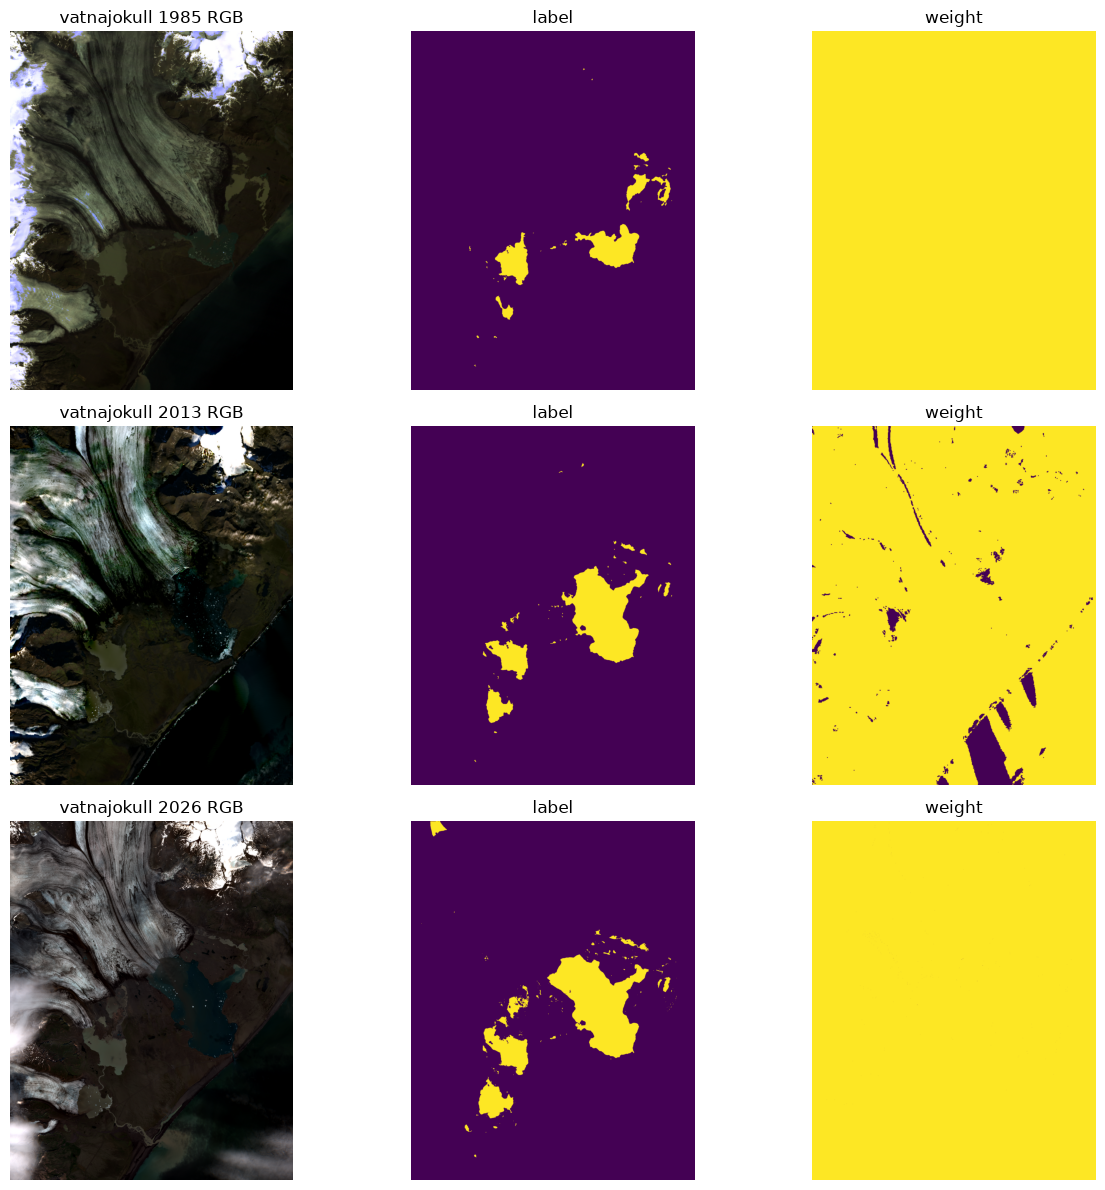

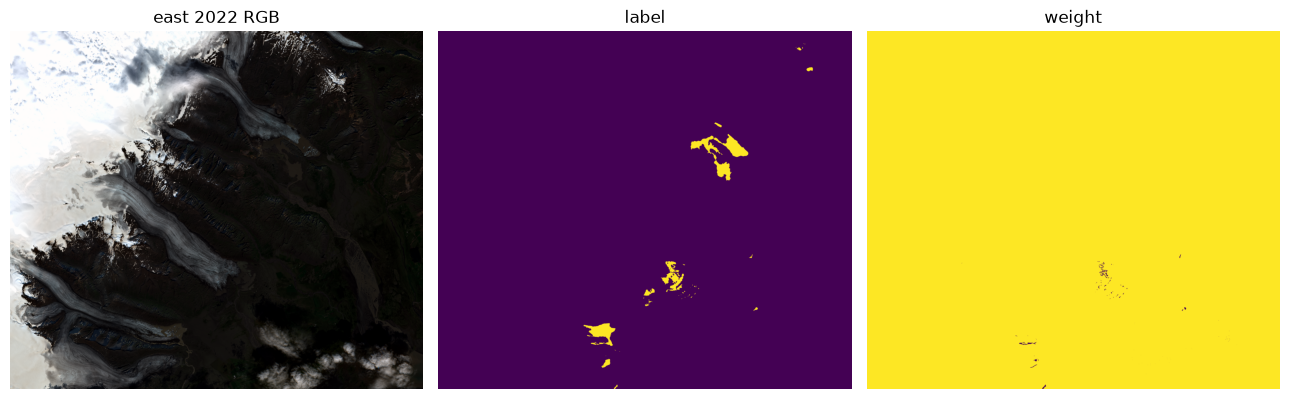

In [6]:
def rgb(area, t, p=(2, 98)):
    i = {b: k for k, b in enumerate(BANDS)}
    a = np.dstack([area["img"][t, i["red"]], area["img"][t, i["green"]], area["img"][t, i["blue"]]])
    lo, hi = np.nanpercentile(a, p)
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)

for area in (train_area, val_area):
    lt = [t for t, k in enumerate(area["ok"]) if k]
    ck = [lt[0], lt[len(lt)//2], lt[-1]] if len(lt) >= 3 else lt
    fig, ax = plt.subplots(len(ck), 3, figsize=(13, 4*len(ck)))
    for row, t in zip(np.atleast_2d(ax), ck):
        row[0].imshow(rgb(area, t));                       row[0].set_title(f"{area['name']} {area['years'][t]} RGB")
        row[1].imshow(area["lab"][t], vmin=0, vmax=1);     row[1].set_title("label")
        row[2].imshow(area["wgt"][t], vmin=0, vmax=1);     row[2].set_title("weight")
        for a in row: a.axis("off")
    plt.tight_layout(); plt.show()

### Chip dataset (training area only)

In [7]:
class LakeChips(Dataset):
    """Random chips from one area, biased toward lake pixels.

    Augmentation matters a lot here: with only a couple of lake systems, flips +
    rotations multiply the effective diversity, and brightness/contrast jitter
    builds robustness to reflectance differences between data providers
    (the exact thing that broke inference on CDSE vs Earth Search).
    """
    def __init__(self, area, chip=128, n=3000, p_lake=0.7, seed=0,
                 jitter=True, rotate=True):
        self.img, self.lab, self.wgt = area["img"], area["lab"], area["wgt"]
        self.t_indices = np.array([t for t, k in enumerate(area["ok"]) if k])
        self.chip, self.n, self.p_lake = chip, n, p_lake
        self.jitter, self.rotate = jitter, rotate
        _, _, Y, X = self.img.shape
        self.Y, self.X = Y - chip, X - chip
        self.rng = np.random.default_rng(seed)
        self.lake_px = {t: np.argwhere((self.lab[t] == 1) & (self.wgt[t] > 0))
                        for t in self.t_indices}

    def __len__(self): return self.n

    def _win(self, t):
        px = self.lake_px[t]
        if self.rng.random() < self.p_lake and len(px):
            cy, cx = px[self.rng.integers(len(px))]
            return (int(np.clip(cy - self.chip//2, 0, self.Y)),
                    int(np.clip(cx - self.chip//2, 0, self.X)))
        return int(self.rng.integers(self.Y)), int(self.rng.integers(self.X))

    def __getitem__(self, i):
        for _ in range(20):
            t = int(self.rng.choice(self.t_indices))
            y, x = self._win(t)
            if self.wgt[t, y:y+self.chip, x:x+self.chip].mean() > 0.3:
                break
        sl = np.s_[y:y+self.chip, x:x+self.chip]
        xi = norm_img(self.img[t, :, y:y+self.chip, x:x+self.chip].copy())
        yi = self.lab[t][sl].copy(); wi = self.wgt[t][sl].copy()

        # --- geometric augmentation (applied to image, label AND weight) ---
        if self.rng.random() < 0.5:
            xi, yi, wi = xi[:, :, ::-1].copy(), yi[:, ::-1].copy(), wi[:, ::-1].copy()
        if self.rng.random() < 0.5:
            xi, yi, wi = xi[:, ::-1, :].copy(), yi[::-1, :].copy(), wi[::-1, :].copy()
        if self.rotate:
            k = int(self.rng.integers(4))          # water has no canonical orientation
            if k:
                xi = np.rot90(xi, k, axes=(1, 2)).copy()
                yi = np.rot90(yi, k).copy()
                wi = np.rot90(wi, k).copy()

        # --- radiometric jitter (image ONLY - never the label) ---
        if self.jitter and self.rng.random() < 0.5:
            gain   = self.rng.uniform(0.85, 1.15)   # contrast
            offset = self.rng.uniform(-0.10, 0.10)  # brightness
            xi = xi * gain + offset

        return (torch.from_numpy(np.ascontiguousarray(xi, dtype=np.float32)),
                torch.from_numpy(np.ascontiguousarray(yi, dtype=np.float32)).unsqueeze(0),
                torch.from_numpy(np.ascontiguousarray(wi, dtype=np.float32)).unsqueeze(0))


train_ds = LakeChips(train_area, n=3000, p_lake=0.7)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
print(f"training on {len(train_ds.t_indices)} labelled {train_area['name']} scenes")
print(f"validating on {sum(val_area['ok'])} labelled {val_area['name']} scenes")

training on 28 labelled vatnajokull scenes
validating on 1 labelled east scenes


### Train

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

# ResNet18 is deliberately kept: with only a couple of lake systems a bigger
# encoder overfits faster rather than generalising better. Data is the
# bottleneck here, not capacity.
model = smp.Unet(encoder_name="resnet18", encoder_weights="imagenet",
                 in_channels=len(BANDS), classes=1).to(device)

EPOCHS = 60
opt = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

cuda


In [9]:
@torch.no_grad()
def predict_scene(area, t):
    x = torch.from_numpy(norm_img(area["img"][t])).unsqueeze(0)
    _, _, Y, X = x.shape
    x = F.pad(x, (0, (32 - X % 32) % 32, 0, (32 - Y % 32) % 32))
    return torch.sigmoid(model(x.to(device)))[0, 0, :Y, :X].cpu().numpy()


def iou_np(pred, targ, where):
    p, t = pred & where, targ & where
    u = (p | t).sum()
    return (p & t).sum() / u if u else np.nan


def evaluate(area=None, thr=0.5):
    """IoU over the held-out AREA's labelled scenes."""
    area = area or val_area
    model.eval()
    s = []
    for t, k in enumerate(area["ok"]):
        if not k:
            continue
        pred = predict_scene(area, t) > thr
        s.append(iou_np(pred, area["lab"][t].astype(bool), area["wgt"][t] > 0))
    return float(np.nanmean(s)) if s else float("nan")

epoch 00  lr 5.0e-04  train-area IoU 0.343   VAL(east) IoU 0.102
epoch 01  lr 5.0e-04  train-area IoU 0.591   VAL(east) IoU 0.309
epoch 02  lr 5.0e-04  train-area IoU 0.478   VAL(east) IoU 0.113
epoch 03  lr 4.9e-04  train-area IoU 0.390   VAL(east) IoU 0.145
epoch 04  lr 4.9e-04  train-area IoU 0.517   VAL(east) IoU 0.267
epoch 05  lr 4.9e-04  train-area IoU 0.760   VAL(east) IoU 0.234
epoch 06  lr 4.8e-04  train-area IoU 0.755   VAL(east) IoU 0.429
epoch 07  lr 4.8e-04  train-area IoU 0.615   VAL(east) IoU 0.147
epoch 08  lr 4.7e-04  train-area IoU 0.642   VAL(east) IoU 0.219
epoch 09  lr 4.7e-04  train-area IoU 0.697   VAL(east) IoU 0.375
epoch 10  lr 4.6e-04  train-area IoU 0.821   VAL(east) IoU 0.428
epoch 11  lr 4.5e-04  train-area IoU 0.771   VAL(east) IoU 0.408
epoch 12  lr 4.4e-04  train-area IoU 0.806   VAL(east) IoU 0.317
epoch 13  lr 4.4e-04  train-area IoU 0.822   VAL(east) IoU 0.344
epoch 14  lr 4.3e-04  train-area IoU 0.788   VAL(east) IoU 0.283
epoch 15  lr 4.2e-04  tra

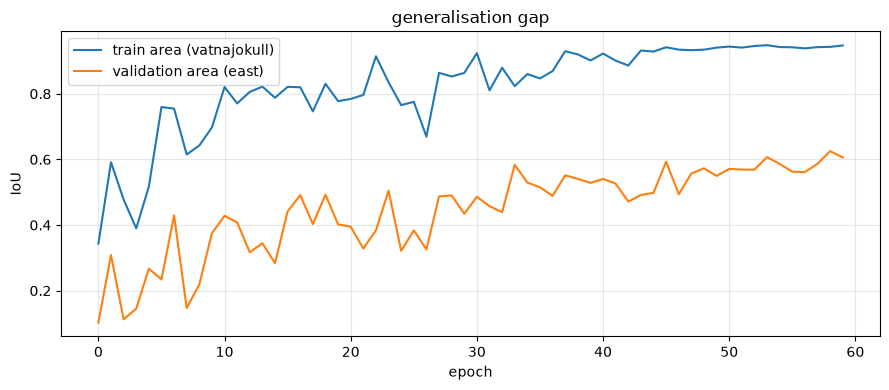

In [10]:
# pos_weight makes a MISSED lake cost more than a false alarm, pushing recall up.
# Your failure mode is high precision / low recall, so weight positives > 1.
POS_WEIGHT = 3.0

def weighted_loss(logits, y, w, eps=1.0):
    pw = torch.tensor(POS_WEIGHT, device=logits.device)
    bce_px = F.binary_cross_entropy_with_logits(logits, y, reduction="none", pos_weight=pw)
    bce = (bce_px * w).sum() / w.sum().clamp(min=1)
    p, yw = torch.sigmoid(logits) * w, y * w
    dice = 1 - (2*(p*yw).sum() + eps) / (p.sum() + yw.sum() + eps)
    return bce + dice


best, best_state, hist = -1.0, None, []
for epoch in range(EPOCHS):
    model.train()
    for xb, yb, wb in train_dl:
        xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
        loss = weighted_loss(model(xb), yb, wb)
        opt.zero_grad(); loss.backward(); opt.step()
    sched.step()

    iou_val   = evaluate(val_area)
    iou_train = evaluate(train_area)
    hist.append((epoch, iou_train, iou_val))
    if iou_val > best:
        best = iou_val
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch:02d}  lr {sched.get_last_lr()[0]:.1e}  "
          f"train-area IoU {iou_train:.3f}   VAL({val_area['name']}) IoU {iou_val:.3f}")

if best_state is not None:
    model.load_state_dict(best_state)
print(f"\nbest validation IoU on {val_area['name']}: {best:.3f}")

# The gap between the two curves is the diagnosis: if train-area IoU climbs high
# while VAL stays low, the model is memorising and only MORE LABELLED AREAS help.
h = np.array(hist)
plt.figure(figsize=(9, 4))
plt.plot(h[:, 0], h[:, 1], label=f"train area ({train_area['name']})")
plt.plot(h[:, 0], h[:, 2], label=f"validation area ({val_area['name']})")
plt.xlabel("epoch"); plt.ylabel("IoU"); plt.legend(); plt.grid(alpha=.3)
plt.title("generalisation gap"); plt.tight_layout(); plt.show()

### Inspect a validation scene

This is the new area the model never trained on — the honest look.

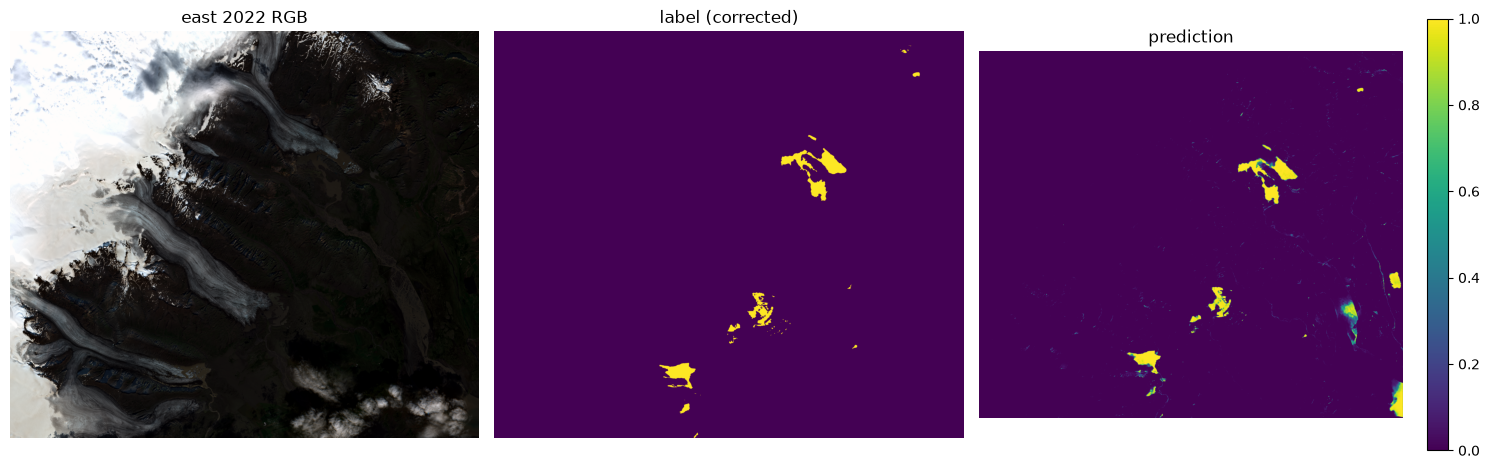

prob max 1.0 | frac>0.5 0.0139


In [12]:
lt = [t for t, k in enumerate(val_area["ok"]) if k]
t = lt[0]
prob = predict_scene(val_area, t)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb(val_area, t));                 ax[0].set_title(f"{val_area['name']} {val_area['years'][t]} RGB")
ax[1].imshow(val_area["lab"][t], vmin=0, vmax=1); ax[1].set_title("label (corrected)")
im = ax[2].imshow(prob, vmin=0, vmax=1);        ax[2].set_title("prediction")
fig.colorbar(im, ax=ax[2], fraction=0.046)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print("prob max", round(float(prob.max()), 3),
      "| frac>0.5", round(float((prob > 0.5).mean()), 4))

### Lake-area time series (per area)

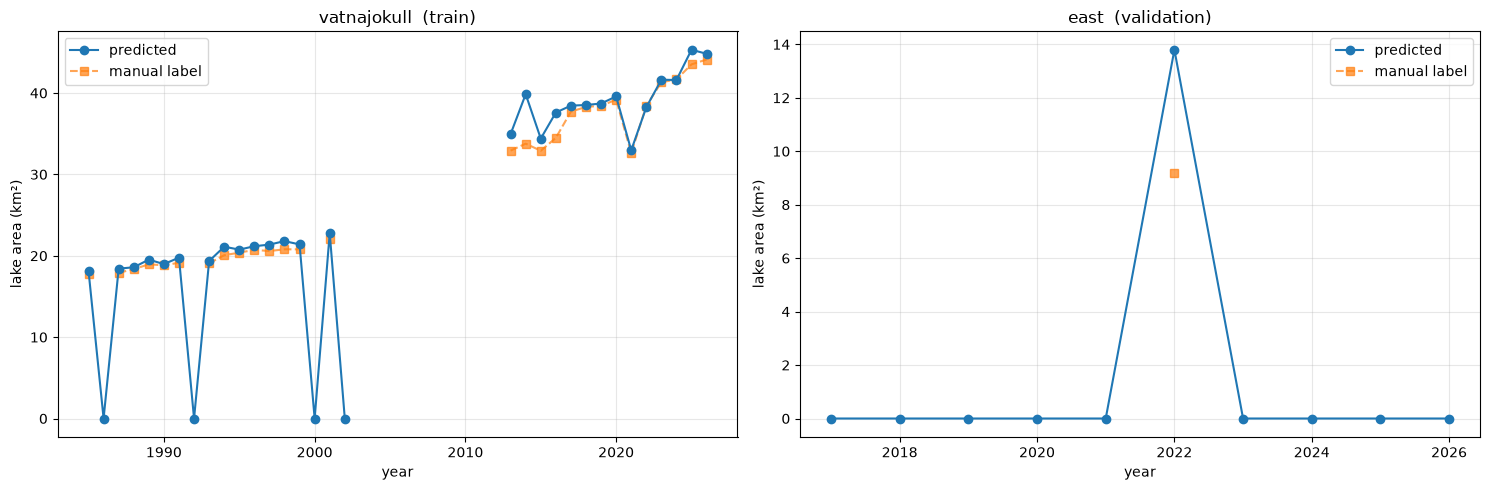

In [15]:
def area_table(area):
    px_km2 = abs(float(area["cube"].x[1] - area["cube"].x[0])) * \
             abs(float(area["cube"].y[1] - area["cube"].y[0])) / 1e6
    rows = []
    for t, y in enumerate(area["years"]):
        prob = predict_scene(area, t)
        valid = area["wgt"][t] > 0
        pred = float(((prob > 0.5) & valid).sum() * px_km2)
        lbl = float((area["lab"][t].astype(bool) & valid).sum() * px_km2) if area["ok"][t] else np.nan
        rows.append((y, lbl, pred))
    df = pd.DataFrame(rows, columns=["year", "label_km2", "pred_km2"]).set_index("year").sort_index()
    return df.reindex(range(df.index.min(), df.index.max() + 1))   # NaN breaks the line at gaps

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for a, area in zip(ax, (train_area, val_area)):
    df = area_table(area)
    a.plot(df.index, df.pred_km2, "-o", label="predicted", zorder=3)
    a.plot(df.index, df.label_km2, "--s", label="manual label", alpha=.7)
    a.set_title(f"{area['name']}  ({'train' if area is train_area else 'validation'})")
    a.set_xlabel("year"); a.set_ylabel("lake area (km²)"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Save model & predictions

In [14]:
ckpt = {
    "state_dict": model.state_dict(),
    "arch": {"encoder_name": "resnet18", "in_channels": len(BANDS), "classes": 1},
    "bands": BANDS,
    # NO fixed mean/std any more: normalisation is PER SCENE.
    # Prediction must apply the identical transform - see standardize_scene.
    "normalization": f"reflectance 0-1, then per-scene per-band p{PLOW:g}-p{PHIGH:g} scaling, clipped [-0.5,1.5]",
    "standardize": {"method": "per_scene_percentile",
                    "p_low": PLOW, "p_high": PHIGH,
                    "clip": [-0.5, 1.5]},
    "bad_years": BAD_YEARS,
    "train_area": train_area["name"],
    "val_area": val_area["name"],
    "val_iou": best,
}
torch.save(ckpt, "unet_lake.pt")
print("bands (order matters for ONNX/openEO):", BANDS)

for area, out in ((train_area, "train_predictions.zarr"),
                  (val_area,   "val_predictions.zarr")):
    probs = np.stack([predict_scene(area, t) for t in range(area["img"].shape[0])])
    xr.Dataset({"prob":  (("year","y","x"), probs.astype("float32")),
                "lake":  (("year","y","x"), (probs > 0.5).astype("uint8")),
                "valid": (("year","y","x"), area["wgt"])},
               coords={"year": area["years"], "y": area["cube"].y, "x": area["cube"].x}
              ).rio.write_crs(TARGET_CRS).to_zarr(out, mode="w")
    print("wrote", out)

bands (order matters for ONNX/openEO): ['blue', 'green', 'nir', 'red']


C:\Users\b1120440\AppData\Local\miniconda3\envs\eocube\Lib\site-packages\zarr\api\asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


wrote train_predictions.zarr
wrote val_predictions.zarr
